# HW4 – EuroSAT 圖庫資料庫（MLP & CNN）

作業說明：
1. 使用 EuroSAT 圖庫資料庫（TFDS: `eurosat/rgb`）
2. **MLP**：調整層數與每層神經元，找出 **test set** 最佳
3. **CNN**：調整層數與每層神經元，找出 **test set** 最佳
4. 比較兩者優劣



In [6]:
import sys
!{sys.executable} -m pip uninstall -y tensorflow-datasets
!{sys.executable} -m pip install -U tensorflow-datasets


Found existing installation: tensorflow-datasets 4.9.9
Uninstalling tensorflow-datasets-4.9.9:
  Successfully uninstalled tensorflow-datasets-4.9.9
  Using cached tensorflow_datasets-4.9.9-py3-none-any.whl.metadata (11 kB)
Using cached tensorflow_datasets-4.9.9-py3-none-any.whl (5.3 MB)


In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TF:", tf.__version__)

import tensorflow_datasets as tfds

print("TFDS module file:", getattr(tfds, "__file__", "N/A"))
print("Has tfds.load ?", hasattr(tfds, "load"))
assert hasattr(tfds, "load")

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


TF: 2.15.1
TFDS module file: /Users/chouyouzhen/.pyenv/versions/3.10.12/lib/python3.10/site-packages/tensorflow_datasets/__init__.py
Has tfds.load ? True


In [8]:
# Resubmitable：固定亂數種子
SEED = 1
tf.random.set_seed(SEED)
np.random.seed(SEED)


## 1) 載入 EuroSAT

TFDS 的 EuroSAT 只有一個 `train` split（總共 27,000）。  

- Train 80%
- Val 10%
- Test 10%


Splits: 21600 2700 2700
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


2026-01-07 15:36:57.059413: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-01-07 15:36:57.059459: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-07 15:36:57.059462: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-07 15:36:57.059631: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-07 15:36:57.059824: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


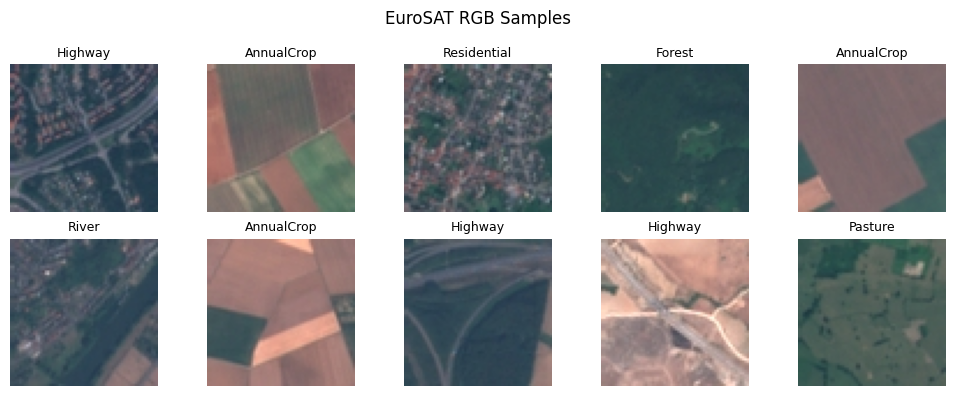

In [9]:
# EuroSAT 
NUM_EXAMPLES = 27000
NUM_CLASSES = 10
IMG_SIZE = (64, 64)

N_TRAIN = int(NUM_EXAMPLES * 0.8)  # 21600
N_VAL   = int(NUM_EXAMPLES * 0.1)  # 2700
N_TEST  = NUM_EXAMPLES - N_TRAIN - N_VAL  # 2700

print("Splits:", N_TRAIN, N_VAL, N_TEST)
import logging
logging.getLogger("tensorflow_datasets").setLevel(logging.ERROR)

(ds_all,), info = tfds.load(
    "eurosat/rgb",
    split=["train"],
    as_supervised=True,
    with_info=True
)

class_names = info.features["label"].names
print("Classes:", class_names)

# Deterministic shuffle -> reproducible split
ds_all = ds_all.shuffle(NUM_EXAMPLES, seed=SEED, reshuffle_each_iteration=False)

ds_train = ds_all.take(N_TRAIN)
ds_rest  = ds_all.skip(N_TRAIN)
ds_val   = ds_rest.take(N_VAL)
ds_test  = ds_rest.skip(N_VAL).take(N_TEST)

# 顯示樣本
plt.figure(figsize=(10,4))
for i, (img, lab) in enumerate(ds_train.take(10)):
    plt.subplot(2,5,i+1)
    plt.imshow(img.numpy())
    plt.title(class_names[int(lab.numpy())], fontsize=9)
    plt.axis("off")
plt.suptitle("EuroSAT RGB Samples")
plt.tight_layout()
plt.show()


## 2) 前處理 + tf.data pipeline


In [10]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)  # 保險：固定成 64x64
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

ds_train_p = (ds_train
              .map(preprocess, num_parallel_calls=AUTOTUNE)
              .cache()
              .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
              .batch(BATCH_SIZE)
              .prefetch(AUTOTUNE))

ds_val_p = (ds_val
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .cache()
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

ds_test_p = (ds_test
             .map(preprocess, num_parallel_calls=AUTOTUNE)
             .cache()
             .batch(BATCH_SIZE)
             .prefetch(AUTOTUNE))


## 3) 建立模型函式：MLP / CNN（可調層數與神經元）


In [11]:
def build_mlp(hidden_units, dropout=0.2, l2_lambda=0.0, lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)))
    model.add(layers.Flatten())
    for u in hidden_units:
        if l2_lambda > 0:
            model.add(layers.Dense(u, activation="relu",
                                   kernel_regularizer=regularizers.l2(l2_lambda)))
        else:
            model.add(layers.Dense(u, activation="relu"))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))
    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_cnn(conv_filters, dense_units, dropout=0.3, l2_lambda=0.0, lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)))

    for f in conv_filters:
        if l2_lambda > 0:
            model.add(layers.Conv2D(f, (3,3), padding="same", activation="relu",
                                    kernel_regularizer=regularizers.l2(l2_lambda)))
        else:
            model.add(layers.Conv2D(f, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    for u in dense_units:
        if l2_lambda > 0:
            model.add(layers.Dense(u, activation="relu",
                                   kernel_regularizer=regularizers.l2(l2_lambda)))
        else:
            model.add(layers.Dense(u, activation="relu"))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))
    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


## 4) 共用訓練設定


In [12]:
EPOCHS = 15  

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]


## 5) Part A：MLP – 多組搜尋


In [13]:
mlp_configs = [
    [256],
    [512],
    [512, 256],
    [1024, 512],
]

mlp_l2s = [0.0, 1e-4]

mlp_results = []
mlp_best = None

for hidden_units in mlp_configs:
    for l2_lambda in mlp_l2s:
        print("="*90)
        print(f"MLP config: units={hidden_units}, dropout=0.2, l2={l2_lambda}")
        model = build_mlp(hidden_units, dropout=0.2, l2_lambda=l2_lambda, lr=1e-3)

        t0 = time.time()
        hist = model.fit(ds_train_p, validation_data=ds_val_p, epochs=EPOCHS, callbacks=callbacks, verbose=2)
        train_sec = time.time() - t0

        best_val_acc = float(max(hist.history["val_accuracy"]))
        test_loss, test_acc = model.evaluate(ds_test_p, verbose=0)

        row = {
            "hidden_units": hidden_units,
            "dropout": 0.2,
            "l2": float(l2_lambda),
            "best_val_acc": best_val_acc,
            "test_acc": float(test_acc),
            "train_sec": float(train_sec),
            "params": int(model.count_params()),
        }
        mlp_results.append(row)
        print(f"Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f} | Time(s): {train_sec:.1f} | Params: {row['params']}")

        if (mlp_best is None) or (test_acc > mlp_best["test_acc"]):
            mlp_best = row

print("\n🏆 MLP BEST:", mlp_best)


MLP config: units=[256], dropout=0.2, l2=0.0
Epoch 1/15


2026-01-07 15:36:58.535160: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


338/338 - 3s - loss: 11.3005 - accuracy: 0.1731 - val_loss: 2.8244 - val_accuracy: 0.2733 - lr: 0.0010 - 3s/epoch - 10ms/step
Epoch 2/15
338/338 - 2s - loss: 4.0380 - accuracy: 0.2519 - val_loss: 2.5214 - val_accuracy: 0.2426 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 3/15
338/338 - 2s - loss: 2.6365 - accuracy: 0.2793 - val_loss: 2.3016 - val_accuracy: 0.2996 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 4/15
338/338 - 2s - loss: 2.4235 - accuracy: 0.2894 - val_loss: 2.0813 - val_accuracy: 0.2970 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 5/15
338/338 - 2s - loss: 2.1564 - accuracy: 0.2981 - val_loss: 2.4014 - val_accuracy: 0.2619 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 6/15

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
338/338 - 2s - loss: 2.1068 - accuracy: 0.3016 - val_loss: 2.2974 - val_accuracy: 0.3011 - lr: 0.0010 - 2s/epoch - 7ms/step
Epoch 7/15
338/338 - 2s - loss: 1.8981 - accuracy: 0.3254 - val_loss: 2.2823 - val_accuracy: 0.2763 - lr: 5.0000e-04 - 2s/

## 6) Part B：CNN – 多組搜尋


In [14]:
cnn_configs = [
    {"conv_filters": [32, 64],       "dense_units": [128]},
    {"conv_filters": [32, 64, 128],  "dense_units": [128]},
    {"conv_filters": [32, 64, 128],  "dense_units": [256]},
    {"conv_filters": [64, 128, 256], "dense_units": [256]},
]

cnn_l2s = [0.0, 1e-4]

cnn_results = []
cnn_best = None

for cfg in cnn_configs:
    for l2_lambda in cnn_l2s:
        print("="*90)
        print(f"CNN config: conv={cfg['conv_filters']}, dense={cfg['dense_units']}, dropout=0.3, l2={l2_lambda}")
        model = build_cnn(cfg["conv_filters"], cfg["dense_units"], dropout=0.3, l2_lambda=l2_lambda, lr=1e-3)

        t0 = time.time()
        hist = model.fit(ds_train_p, validation_data=ds_val_p, epochs=EPOCHS, callbacks=callbacks, verbose=2)
        train_sec = time.time() - t0

        best_val_acc = float(max(hist.history["val_accuracy"]))
        test_loss, test_acc = model.evaluate(ds_test_p, verbose=0)

        row = {
            "conv_filters": cfg["conv_filters"],
            "dense_units": cfg["dense_units"],
            "dropout": 0.3,
            "l2": float(l2_lambda),
            "best_val_acc": best_val_acc,
            "test_acc": float(test_acc),
            "train_sec": float(train_sec),
            "params": int(model.count_params()),
        }
        cnn_results.append(row)
        print(f"Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f} | Time(s): {train_sec:.1f} | Params: {row['params']}")

        if (cnn_best is None) or (test_acc > cnn_best["test_acc"]):
            cnn_best = row

print("\n🏆 CNN BEST:", cnn_best)


CNN config: conv=[32, 64], dense=[128], dropout=0.3, l2=0.0
Epoch 1/15
338/338 - 6s - loss: 1.6440 - accuracy: 0.4146 - val_loss: 1.0996 - val_accuracy: 0.6048 - lr: 0.0010 - 6s/epoch - 18ms/step
Epoch 2/15
338/338 - 5s - loss: 1.1901 - accuracy: 0.5868 - val_loss: 0.8582 - val_accuracy: 0.7019 - lr: 0.0010 - 5s/epoch - 14ms/step
Epoch 3/15
338/338 - 5s - loss: 0.9726 - accuracy: 0.6704 - val_loss: 0.9735 - val_accuracy: 0.6711 - lr: 0.0010 - 5s/epoch - 14ms/step
Epoch 4/15
338/338 - 5s - loss: 0.8609 - accuracy: 0.7081 - val_loss: 0.7215 - val_accuracy: 0.7522 - lr: 0.0010 - 5s/epoch - 14ms/step
Epoch 5/15
338/338 - 5s - loss: 0.8701 - accuracy: 0.7078 - val_loss: 0.8501 - val_accuracy: 0.6981 - lr: 0.0010 - 5s/epoch - 14ms/step
Epoch 6/15

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
338/338 - 5s - loss: 0.8346 - accuracy: 0.7220 - val_loss: 0.7951 - val_accuracy: 0.7333 - lr: 0.0010 - 5s/epoch - 14ms/step
Epoch 7/15
338/338 - 5s - loss: 0.7017 - accura

## 7) 比較 MLP vs CNN（優劣分析）


In [16]:
print("===== Summary (BEST by Test Accuracy) =====")
print("MLP BEST :")
print("  test_acc :", mlp_best["test_acc"])
print("  params   :", mlp_best["params"])
print("  train_sec:", mlp_best["train_sec"])

print("\nCNN BEST :")
print("  test_acc :", cnn_best["test_acc"])
print("  params   :", cnn_best["params"])
print("  train_sec:", cnn_best["train_sec"])

better = "CNN" if cnn_best["test_acc"] >= mlp_best["test_acc"] else "MLP"
print(f"\nConclusion: 在本次 EuroSAT 設定下，{better} 的 test accuracy 較佳。")


===== Summary (BEST by Test Accuracy) =====
MLP BEST :
  test_acc : 0.40481480956077576
  params   : 3148554
  train_sec: 46.89226293563843

CNN BEST :
  test_acc : 0.869259238243103
  params   : 2193226
  train_sec: 114.32958722114563

Conclusion: 在本次 EuroSAT 設定下，CNN 的 test accuracy 較佳。
